In [1]:
import sys, socket, os
from pathlib import Path
protected = [Path.cwd() / 'data', Path.cwd() / 'upstream']
def audit_raw_writes(event, args):
    if event == 'open' and isinstance(args[0], (str, bytes, os.PathLike)):
        path = Path(os.fsdecode(args[0])).resolve()
        mode, flags = args[1], args[2]
        write = (isinstance(mode, str) and any(c in mode for c in 'wax+')) or (isinstance(flags, int) and flags & (os.O_WRONLY | os.O_RDWR | os.O_CREAT | os.O_TRUNC))
        if write and any(path == p or path.is_relative_to(p) for p in protected):
            raise RuntimeError('Protected raw write attempted: ' + str(path))
def no_network(*args, **kwargs):
    raise RuntimeError('Network disabled for inspection verification')
sys.dont_write_bytecode = True
sys.addaudithook(audit_raw_writes)
socket.socket.connect = no_network
socket.create_connection = no_network

blocked_raw = Path.cwd() / 'data' / 'llmx_data'
blocked_schema = Path.cwd() / 'outputs/dataset_inventory' / 'llmx_schema.json'
def audit_scope(event, args):
    if event in ('open', 'os.scandir') and isinstance(args[0], (str, bytes, os.PathLike)):
        path = Path(os.fsdecode(args[0])).resolve()
        if path == blocked_schema or path == blocked_raw or path.is_relative_to(blocked_raw):
            raise RuntimeError('Other dataset scope accessed: ' + str(path))
sys.addaudithook(audit_scope)


# 外部candidate dataset: raw scan / token inspection

現在のrawファイルをread-onlyで検査し、raw → preprocessing → prompt → local tokenizerを確認します。
このNotebook単独で上から実行できます。もう一方のデータ調査は [01_data_and_token_inspection.ipynb](01_data_and_token_inspection.ipynb) に分離しています。
data/の変更・ダウンロード・モデル推論・API呼び出しは行いません。結果はメモリ上に保持します。

全体scan → 一覧 → 保存inventoryとの任意比較 → 選択record → 対象範囲のtoken計測・比較の順です。


## 1. imports / path

scan対象directory、実ファイルのschemaを取得する関数、reader、preprocessing、token counterを明示します。


In [2]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset_adapters").is_dir() and (p / "configs/sources.json").is_file()), None)
if ROOT is None:
    raise RuntimeError("workspace直下またはnotebooks/から起動してください。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.inventory_candidates import scan
from dataset_adapters.base import inventory_context
from dataset_adapters.registry import get_adapter, EXTERNAL
from tools.live_inspection import (
    external_frames, compare_frames, show_frame,
    token_summary_frame, compare_saved_tokens,
)
from tools.notebook_inspection import (
    select_record, preview_raw, preprocessing_for_inspection,
    selected_query, token_record, read_batch_summary,
)
from tools.count_input_tokens import resolve_encoding
from tools.token_inventory import build_token_inventory

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
print("External raw:", ROOT / "data/candidate_datasets")
print("No API clients. Scan/token results stay in memory; saved inventories are not overwritten.")


External raw: /Users/cls-lab/Git/Matsuo/mental-modeling-openai/data/candidate_datasets
No API clients. Scan/token results stay in memory; saved inventories are not overwritten.


## 2. LIVE SCAN: external raw

scan()が現在取得済みの全ファイルを再帰scanします。
CSV/TXT/MAT/ULog/XLSXは既存の安全なreaderで確認し、code/model/media等はmetadataのみです。
opaque MATLAB objectは未解釈のまま示します。scan内の個別ファイルerrorも後の表に残し、成功扱いしません。


In [3]:
candidate_inventory = scan(ROOT / "data/candidate_datasets")
print("LIVE external files:", len(candidate_inventory["files"]))
print("Source size/mtime unchanged:", candidate_inventory["source_size_mtime_unchanged"])
print("Read errors:", sum(f["status"] == "error" for f in candidate_inventory["files"]))


Scanned 1000/34046


Scanned 2000/34046


Scanned 3000/34046


Scanned 4000/34046


Scanned 5000/34046


...

Scanned 31000/34046


Scanned 32000/34046


Scanned 33000/34046


Scanned 34000/34046


LIVE external files: 34046
Source size/mtime unchanged: True
Read errors: 0


## 3. external全file / schema / column shape

candidate_inventory objectから作成。external_files_dfは全取得物、external_columns_dfはcolumn schema、
external_arrays_dfはMAT/NPZ/ULogの配列shape/dtypeです。CSVのdtypeはinventory readerの型解釈で、ファイル固有のbinary dtypeではありません。

外部は数万ファイルあるため、表示だけページに分けます。全件は各DataFrameに保持しています。
EXTERNAL_FILE_START / EXTERNAL_COLUMN_START / EXTERNAL_ARRAY_STARTを変更してこのセルを再実行するか、query()で絞り込めます。
missingが未報告の形式はnullであり0を捏造しません。


In [4]:
external_datasets_df, external_files_df, external_schema_groups_df, external_columns_df, external_arrays_df = external_frames(candidate_inventory)
EXTERNAL_FILE_START = 0
EXTERNAL_COLUMN_START = 0
EXTERNAL_ARRAY_START = 0
PAGE_SIZE = 100
show_frame(external_datasets_df, title="LIVE external_datasets_df")
show_frame(external_files_df, title="LIVE external_files_df", start=EXTERNAL_FILE_START, page_size=PAGE_SIZE)
show_frame(external_schema_groups_df, title="LIVE external_schema_groups_df")
show_frame(external_columns_df, title="LIVE external_columns_df", start=EXTERNAL_COLUMN_START, page_size=PAGE_SIZE)
show_frame(external_arrays_df, title="LIVE external_arrays_df", start=EXTERNAL_ARRAY_START, page_size=PAGE_SIZE)
scan_errors_df = external_files_df.query("status == 'error'")
if not scan_errors_df.empty:
    display(scan_errors_df)


,dataset,file_count,disk_bytes_excluding_git_cache,compressed_bytes_all_zip_including_nested,compressed_bytes_top_level,extracted_bytes_excluding_nested_zip,format_counts,schema_group_count,errors
0,aircombat_wez,17,462715,0,0,462715,"{'.csv': 12, 'no_extension': 1, '.md': 1, '.ipynb': 1, '.py': 1, '.txt': 1}",12,[]
1,calculated_moves,30616,1870396977,433793427,211171930,1436603550,"{'.zip': 4, 'no_extension': 10, '.txt': 12601, '.csv': 18001}",25,[]
2,f16capstone,210,256752038,0,0,256752038,"{'no_extension': 6, '.mat': 8, '.md': 35, '.py': 2, '.txt': 1, '.m': 35, '.heic': 1, '.mov': 1, '.ulg': 3, '.slx': 4, '.pdf': 58, '.png': 6, '.xlsx': 5, '.csv': 3, '.mpp': 1, '.f3z': 1, '.f3d': 1, '.stl': 1, '.jpg': 28, '.jpeg': 1, '.kml': 1, '.xml': 7, '.json': 1}",33,[]
3,trajair,3203,2464731087,316594152,316594152,2148136935,"{'.zip': 2, '.txt': 3089, '.csv': 112}",13,[]


,dataset,relative_path,format,size_bytes,rows,columns,schema_group,status
0,aircombat_wez,repository/Data/FactorialExperiment.csv,.csv,49720,864.0,10.0,aircombat_wez:15ed781ce07cec18,inspected
1,aircombat_wez,repository/Data/RandomExperiment_1000_NEZ.csv,.csv,52430,1000.0,10.0,aircombat_wez:3400173d0f20724e,inspected
2,aircombat_wez,repository/Data/RandomExperiment_1000_RMAX.csv,.csv,53865,1000.0,10.0,aircombat_wez:616c9b29c95caed1,inspected
3,aircombat_wez,repository/Data/RandomExperiment_1000_WEZ.csv,.csv,76481,1000.0,13.0,aircombat_wez:b2484680644a27b8,inspected
4,aircombat_wez,repository/LICENSE,no_extension,7048,121.0,NaN,aircombat_wez:8372931050a8036b,inspected
5,aircombat_wez,repository/Paper_Results/SummaryRMax_Lasso_Ridge_50_Reduction.csv,.csv,36823,60.0,39.0,aircombat_wez:cf7d844fac86530a,inspected
6,aircombat_wez,repository/Paper_Results/SummaryRMax_RF_50_.csv,.csv,1215,1.0,39.0,aircombat_wez:cf7d844fac86530a,inspected
7,aircombat_wez,repository/Paper_Results/SummaryRNez_RF_50_.csv,.csv,1218,1.0,39.0,aircombat_wez:f2520c736d775ba3,inspected
8,aircombat_wez,repository/Paper_Results/SummaryWez_Final_Results.csv,.csv,7030,7.0,53.0,aircombat_wez:3f2420d4132708e6,inspected
9,aircombat_wez,repository/Paper_Results/SummaryWez_Lasso_50_Preprocessing_Comparison.csv,.csv,35689,40.0,53.0,aircombat_wez:3f2420d4132708e6,inspected


,dataset,schema_group,file_count,rows,schema_kind,example_file
0,aircombat_wez,aircombat_wez:15ed781ce07cec18,1,864,delimited,repository/Data/FactorialExperiment.csv
1,aircombat_wez,aircombat_wez:3400173d0f20724e,1,1000,delimited,repository/Data/RandomExperiment_1000_NEZ.csv
2,aircombat_wez,aircombat_wez:616c9b29c95caed1,1,1000,delimited,repository/Data/RandomExperiment_1000_RMAX.csv
3,aircombat_wez,aircombat_wez:b2484680644a27b8,1,1000,delimited,repository/Data/RandomExperiment_1000_WEZ.csv
4,aircombat_wez,aircombat_wez:8372931050a8036b,2,127,unstructured_text,repository/LICENSE
5,aircombat_wez,aircombat_wez:cf7d844fac86530a,2,61,delimited,repository/Paper_Results/SummaryRMax_Lasso_Ridge_50_Reduction.csv
6,aircombat_wez,aircombat_wez:f2520c736d775ba3,1,1,delimited,repository/Paper_Results/SummaryRNez_RF_50_.csv
7,aircombat_wez,aircombat_wez:3f2420d4132708e6,4,88,delimited,repository/Paper_Results/SummaryWez_Final_Results.csv
8,aircombat_wez,aircombat_wez:5e10945a47b3304f,1,36,delimited,repository/Paper_Results/SummaryWez_Ridge_Lasso_PR_1to12.csv
9,aircombat_wez,aircombat_wez:a726919e93d47d7f,1,0,support_file,repository/README.md


,dataset,schema_group,column,dtype,rows,missing,schema_kind
0,aircombat_wez,aircombat_wez:15ed781ce07cec18,Case,int64,864,0.0,delimited
1,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Speed,int64,864,0.0,delimited
2,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Speed,int64,864,0.0,delimited
3,aircombat_wez,aircombat_wez:15ed781ce07cec18,rad,int64,864,0.0,delimited
4,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Hdg,int64,864,0.0,delimited
5,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Hdg,int64,864,0.0,delimited
6,aircombat_wez,aircombat_wez:15ed781ce07cec18,BL_Alt,float64,864,0.0,delimited
7,aircombat_wez,aircombat_wez:15ed781ce07cec18,RD_Alt,float64,864,0.0,delimited
8,aircombat_wez,aircombat_wez:15ed781ce07cec18,maxRange,float64,864,0.0,delimited
9,aircombat_wez,aircombat_wez:15ed781ce07cec18,minErrorTry,float64,864,0.0,delimited


,dataset,relative_path,format,key,shape,dtype,ndim,opaque
0,f16capstone,repository/FlightAxis/13_05_2021__16_16_38.mat,.mat,vals,[1],"[('_TypeSystem', 'O'), ('_Class', 'O'), ('_ObjectMetadata', 'O')]",1,True
1,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/timestamp,[119],uint64,1,False
2,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/armed_time_ms,[119],uint32,1,False
3,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/armed,[119],int8,1,False
4,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/prearmed,[119],int8,1,False
5,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/ready_to_arm,[119],int8,1,False
6,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/lockdown,[119],int8,1,False
7,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/manual_lockdown,[119],int8,1,False
8,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/force_failsafe,[119],int8,1,False
9,f16capstone,repository/FlightData/FlightTest1/log_52_2021-5-22-12-42-56.ulg,.ulg,actuator_armed/0/in_esc_calibration_mode,[119],int8,1,False


## 4. LIVE SCAN vs SAVED INVENTORY — secondary validation

ここで初めて保存済みinventoryを読みます。ファイルがない場合もlive inspectionは可能です。
全件のkeyでouter joinし、新規／削除／shape・dtype変更・件数差を隠しません。
一致しなくてもrawを変更したりcacheを上書きしたりしません。


In [5]:
saved_base = ROOT / "outputs/dataset_inventory"
raw_validation = {}
if (saved_base / "candidate_schema.json").is_file():
    saved_candidates = json.loads((saved_base / "candidate_schema.json").read_text())
    _, saved_external_files, _, saved_external_columns, saved_external_arrays = external_frames(saved_candidates)
    raw_validation["external_files"] = compare_frames(
        external_files_df, saved_external_files, ["dataset", "relative_path"],
        ["size_bytes", "rows", "columns", "schema_group", "status"])
    raw_validation["external_columns"] = compare_frames(
        external_columns_df, saved_external_columns, ["dataset", "schema_group", "column"], ["dtype", "rows", "missing"])
    raw_validation["external_arrays"] = compare_frames(
        external_arrays_df, saved_external_arrays, ["dataset", "relative_path", "key"], ["shape", "dtype", "ndim", "opaque"])
    display(pd.DataFrame([{"comparison": name, "rows": len(table),
                          "matches": int(table.matches.sum()), "differences": int((~table.matches).sum())}
                         for name, table in raw_validation.items()]))
    for name, table in raw_validation.items():
        if not table.matches.all():
            show_frame(table.loc[~table.matches], title=name + " differences", page_size=30)
else:
    print("Saved inventory not found. LIVE scan results remain the primary source.")


,comparison,rows,matches,differences
0,external_files,34046,34036,10
1,external_columns,919,919,0
2,external_arrays,7432,7432,0


,dataset,relative_path,size_bytes_live,rows_live,columns_live,schema_group_live,status_live,size_bytes_saved,rows_saved,columns_saved,schema_group_saved,status_saved,presence,matches
18,calculated_moves,extracted/Dataset Calculated Moves/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
20,calculated_moves,extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
4222,calculated_moves,extracted/Dataset Calculated Moves/Chapter 4 - Rewards/Chapter 4 - Rewards/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
4223,calculated_moves,extracted/Dataset Calculated Moves/Chapter 4 - Rewards/Chapter 4 - Rewards/aareward/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
8424,calculated_moves,extracted/Dataset Calculated Moves/Chapter 4 - Rewards/Chapter 4 - Rewards/binreward/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
12625,calculated_moves,extracted/Dataset Calculated Moves/Chapter 4 - Rewards/Chapter 4 - Rewards/domainreward/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
16827,calculated_moves,extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
16828,calculated_moves,extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v1-transfer-sources/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
21029,calculated_moves,extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False
25830,calculated_moves,extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-transfer-with-mixed-as-source/.DS_Store,6148,NaN,NaN,"""calculated_moves:fd08a77abc1c423f""","""inspected""",NaN,NaN,NaN,NaN,NaN,left_only,False


## 5. drill-down selection

全体を見た後、ここでdatasetを選びます。番号は0-basedです。
選択を変更したら「selected raw record」から「selected query token」まで再実行してください。
外部のみ選択可能: f16capstone / trajair / aircombat_wez / calculated_moves / baidu_fighter_jet（未取得）。
staticのROW_IDは全reader単位の累積IDです。前処理は本projectのexample / baselineであり、raw datasetそのものではありません。


In [6]:
DATASET = "f16capstone"
EPISODE = 0
SEQUENCE_ID = None
ROW_ID = None
INDEX = 10

HISTORY_SIZE = 1
METRIC = None
QUESTION_NAME = None  # 外部baselineでは通常None。
MODEL = "gpt-4o"
# 外部は明示した既存設定のみ。例: "configs/preprocessing/f16capstone_default.yaml"
PREPROCESSING_CONFIG = "configs/preprocessing/f16capstone_default.yaml"


## 6. selected raw record — RAW DATA

readerには同じlive inventoryを渡します。保存済みcacheをprimary sourceへ戻しません。
source file、選択sequence、全raw fieldのshape/dtypeと実値を表示します。


In [7]:
if DATASET not in EXTERNAL:
    raise ValueError("このNotebookの対象外datasetです。もう一方のNotebookを使用してください。")
with inventory_context({"tasks": []}, candidate_inventory):
    adapter = get_adapter(DATASET)
sequence, raw_record = select_record(adapter, episode=EPISODE, sequence_id=SEQUENCE_ID, row_id=ROW_ID, index=INDEX)
if sequence is None:
    print("NOT_ACQUIRED: raw inspection unavailable.")
else:
    print("RAW RECORD")
    print("Source:", sequence.source_file, "\nSequence:", sequence.sequence_id, sequence.key)
    print("Episode:", raw_record["episode_id"], "Row:", raw_record.get("row_id"), "Index:", raw_record["index"])
    print("SHA256:", raw_record["source_file_sha256"])
    raw_fields_df = pd.DataFrame([{"field": name, **spec} for name, spec in raw_record["fields"].items()])
    show_frame(raw_fields_df, title="Selected raw fields")
    print(json.dumps(raw_record["fields"], ensure_ascii=False, indent=2))
    raw_preview = preview_raw(adapter, sequence)
    if isinstance(raw_preview, dict):
        for key, value in raw_preview.items():
            print("\n", key, "(episode scope)" if key == "episodic_return" else "[:5]")
            print(value)
    else:
        display(raw_preview)


RAW RECORD
Source: data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv 
Sequence: 0 repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv
Episode: None Row: None Index: 10
SHA256: 60296b42a9a30f470e75ad7402dd7c04a8cc85ae7738fa57b5332df9e384be4f


,field,value,dtype,shape
0,m-airspeed-MPS,0.0076530540022480085,<U21,[]
1,m-altitudeASL-MTR,0.07124708281594616,<U19,[]
2,m-altitudeAGL-MTR,0.07124708281594616,<U19,[]
3,m-groundspeed-MPS,0.0020938503665184523,<U21,[]
4,m-pitchRate-DEGpSEC,2.2241799044372783,<U18,[]
5,m-rollRate-DEGpSEC,-0.28021970109307404,<U20,[]
6,m-yawRate-DEGpSEC,0.21845430381995357,<U19,[]
7,m-azimuth-DEG,0.23569676280021667,<U19,[]
8,m-inclination-DEG,-0.29912078380584717,<U20,[]
9,m-roll-DEG,0.3909929096698761,<U18,[]


{
  "m-airspeed-MPS": {
    "value": "0.0076530540022480085",
    "dtype": "<U21",
    "shape": []
  },
  "m-altitudeASL-MTR": {
    "value": "0.07124708281594616",
    "dtype": "<U19",
    "shape": []
  },
  "m-altitudeAGL-MTR": {
    "value": "0.07124708281594616",
    "dtype": "<U19",
    "shape": []
  },
  "m-groundspeed-MPS": {
    "value": "0.0020938503665184523",
    "dtype": "<U21",
    "shape": []
  },
  "m-pitchRate-DEGpSEC": {
    "value": "2.2241799044372783",
    "dtype": "<U18",
    "shape": []
  },
  "m-rollRate-DEGpSEC": {
    "value": "-0.28021970109307404",
    "dtype": "<U20",
    "shape": []
  },
  "m-yawRate-DEGpSEC": {
    "value": "0.21845430381995357",
    "dtype": "<U19",
    "shape": []
  },
  "m-azimuth-DEG": {
    "value": "0.23569676280021667",
    "dtype": "<U19",
    "shape": []
  },
  "m-inclination-DEG": {
    "value": "-0.29912078380584717",
    "dtype": "<U20",
    "shape": []
  },
  "m-roll-DEG": {
    "value": "0.3909929096698761",
    "dtype": "<U1

,index,m-airspeed-MPS,m-altitudeASL-MTR,m-altitudeAGL-MTR,m-groundspeed-MPS,m-pitchRate-DEGpSEC,m-rollRate-DEGpSEC,m-yawRate-DEGpSEC,m-azimuth-DEG,m-inclination-DEG,m-roll-DEG,m-aircraftPositionX-MTR,m-aircraftPositionY-MTR,m-velocityWorldU-MPS,m-velocityWorldV-MPS,m-velocityWorldW-MPS,m-velocityBodyU-MPS,m-velocityBodyV-MPS,m-velocityBodyW-MPS,m-accelerationWorldAX-MPS2,m-accelerationWorldAY-MPS2,m-accelerationWorldAZ-MPS2,m-accelerationBodyAX-MPS2,m-accelerationBodyAY-MPS2,m-accelerationBodyAZ-MPS2,m-windX-MPS,m-windY-MPS,m-windZ-MPS,m-propRPM,m-heliMainRotorRPM,m-batteryVoltage-VOLTS,m-batteryCurrentDraw-AMPS,m-batteryRemainingCapacity-MAH,m-fuelRemaining-OZ,m-isLocked,m-hasLostComponents,m-anEngineIsRunning,m-isTouchingGround,m-currentPhysicsTime-SEC,m-currentPhysicsSpeedMultiplier,m-orientationQuaternion-X,m-orientationQuaternion-Y,m-orientationQuaternion-Z,m-orientationQuaternion-W,rc_channel_0,rc_channel_1,rc_channel_2,rc_channel_3,rc_channel_4,rc_channel_5,rc_channel_6,rc_channel_7,rc_channel_8,rc_channel_9,rc_channel_10,rc_channel_11
0,0,0.00555139230374887,0.07121964535518455,0.07121964535518455,0.005146647335692136,0.10493183027173814,0.30565767204302574,-0.0816177945729919,0.2078419029712677,-0.30350154638290405,0.3856721818447113,63.649269104003906,64.29619598388672,0.004775706212967634,0.001918491325341165,0.002080859849229455,0.004779670387506485,0.0019495952874422073,0.0020424933172762394,2.1586103439331055,-0.00783457886427641,9.818084716796875,1.9995925463736057,-0.46166473627090454,-8.997926712036133,0,0,0,20922.49609375,-1,24.23939634633473,7.371776103973389,3603.445068359375,-1,False,False,True,True,144.2885386685375,1,-0.002654633019119501,0.0033607976511120796,0.0018048312049359083,0.9999891519546509,0.5,0.5,0.5,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0
1,1,0.008321079895161251,0.07123535115543511,0.07123535115543511,0.0072152868035204034,1.1859361392012033,0.26605551703818264,0.26381646909339906,0.20879662036895752,-0.29925259947776794,0.38770729303359985,63.649269104003906,64.2962875366211,0.006834238301962614,-0.0023137740790843964,0.004144877195358276,0.006864179857075214,-0.002260996028780937,0.00412447564303875,2.1578822135925293,-0.007843761704862118,9.817922592163086,-0.3426456041634083,-0.3007046729326248,-7.675017833709717,0,0,0,20922.4765625,-1,24.239255977563616,7.371720790863037,3603.408935546875,-1,False,False,True,True,144.30615586834028,1,-0.0026176143437623978,0.0033786026760935783,0.001813241047784686,0.9999892711639404,0.5,0.5,0.5,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0
2,2,0.006045393194438805,0.07124075144360686,0.07124075144360686,0.00557430662603162,-0.43871081698648595,-0.12442270781312459,0.5223823372723473,0.2120172083377838,-0.29924145340919495,0.38748010993003845,63.64924621582031,64.29634094238281,0.004034258890897036,-0.003846771316602826,0.0023396334145218134,0.004060629289597273,-0.0038160497788339853,0.0023443177342414856,2.1584577560424805,-0.007935664616525173,9.817926406860352,-0.16824742034077644,-0.19089962542057037,-8.919336318969727,0,0,0,20922.390625,-1,24.23918266393794,7.371674537658691,3603.39013671875,-1,False,False,True,True,144.31530706817284,1,-0.00261760875582695,0.003376547247171402,0.0018413515063002706,0.9999890327453613,0.5,0.5,0.5,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0
3,3,0.005588964099998627,0.07124251369071422,0.07124251369071422,0.005208870706421626,-0.3802713214501523,-0.18094957706409787,0.7141653408172033,0.2151716947555542,-0.2999512851238251,0.38710692524909973,63.64922332763672,64.29635620117188,0.002126024104654789,-0.004755245056003332,0.0020258789882063866,0.0021544434130191803,-0.004733507055789232,0.0020466549322009087,2.1584348678588867,-0.008046566508710384,9.817947387695312,-0.12355591356754303,-0.1423710659146309,-8.916732788085938,0,0,0,20922.33203125,-1,24.239137960507648,7.3716349601745605,3603.378662109375,-1,False,False,True,True,144.32083216821775,1,-0.0026238898281008005,0.0033732065930962563,0.001868866616860032,0.9999890923500061,0.5,0.

## 7. PREPROCESSING → HISTORY

RAWとMODEL INPUT AFTER PREPROCESSINGは別です。
外部は指定YAMLのexample / baseline変換です。raw datasetそのものではありません。存在しないreward/actionの生成や欠損値の0埋めはしません。


In [8]:
config, preprocessing_status = preprocessing_for_inspection(DATASET, PREPROCESSING_CONFIG)
print(preprocessing_status)
query = None
if config is not None and sequence is not None:
    display(config)
    try:
        query = selected_query(adapter, sequence, raw_record["index"], config, HISTORY_SIZE, METRIC, QUESTION_NAME)
    except (ValueError, IndexError) as exc:
        print("Model input: N/A —", exc)
    if query is not None:
        print("MODEL INPUT AFTER PREPROCESSING:", config["prompt_mode"])
        print("Metric / question:", query.metric, query.question_name)
        print("H:", query.history_size, "history [start,end):", query.history_start, query.history_end)
        print("\nHISTORY\n", query.history_text)
else:
    print("Token count: N/A")


Model-input preprocessing: defined


{'name': 'f16capstone_example_baseline',
 'dataset_id': 'f16capstone',
 'prompt_mode': 'external_generic',
 'source_globs': ['data/candidate_datasets/f16capstone/**/*.csv'],
 'state_columns': ['m-airspeed-MPS',
  'm-altitudeASL-MTR',
  'm-azimuth-DEG',
  'm-inclination-DEG',
  'm-roll-DEG',
  'm-aircraftPositionX-MTR',
  'm-aircraftPositionY-MTR'],
 'action_columns': ['rc_channel_0',
  'rc_channel_1',
  'rc_channel_2',
  'rc_channel_3'],
 'reward_column': None,
 'timestamp_column': 'm-currentPhysicsTime-SEC',
 'gap_policy': 'preserve',
 'value_format': 'lexical',
 'system_prompt': 'Describe only the supplied flight observations and control channels. Do not infer missing measurements or rewards.',
 'question': 'Summarize the supplied observations; distinguish measured values from interpretation.'}

MODEL INPUT AFTER PREPROCESSING: external_generic
Metric / question: representation baseline_description
H: 1 history [start,end): 9 11

HISTORY
 Step 9:
{
  "action": {
    "rc_channel_0": "0.5",
    "rc_channel_1": "0.5",
    "rc_channel_2": "0.5",
    "rc_channel_3": "0.5"
  },
  "state": {
    "m-aircraftPositionX-MTR": "63.649166107177734",
    "m-aircraftPositionY-MTR": "64.29647827148438",
    "m-airspeed-MPS": "0.007784072798286017",
    "m-altitudeASL-MTR": "0.07125134763562091",
    "m-azimuth-DEG": "0.23408009111881256",
    "m-inclination-DEG": "-0.30103498697280884",
    "m-roll-DEG": "0.39236101508140564"
  },
  "timestamp": {
    "m-currentPhysicsTime-SEC": "144.3709200678859"
  }
}

Step 10:
{
  "action": {
    "rc_channel_0": "0.5",
    "rc_channel_1": "0.5",
    "rc_channel_2": "0.5",
    "rc_channel_3": "0.5"
  },
  "state": {
    "m-aircraftPositionX-MTR": "63.64916229248047",
    "m-aircraftPositionY-MTR": "64.2965087890625",
    "m-airspeed-MPS": "0.00765305400224

## 8. actual prompt全文

同じpreprocessingが作ったSYSTEM PROMPTとUSER PROMPT。文字列を表示するだけで送信しません。


In [9]:
if query is not None:
    print("Prompt mode:", config["prompt_mode"], "Preprocessing:", config["name"])
    print("\nSYSTEM PROMPT\n")
    print(query.system_prompt)
    print("\nUSER PROMPT\n")
    print(query.user_prompt)
else:
    print("Prompt: N/A")


Prompt mode: external_generic Preprocessing: f16capstone_example_baseline

SYSTEM PROMPT

Describe only the supplied flight observations and control channels. Do not infer missing measurements or rewards.

USER PROMPT

Step 9:
{
  "action": {
    "rc_channel_0": "0.5",
    "rc_channel_1": "0.5",
    "rc_channel_2": "0.5",
    "rc_channel_3": "0.5"
  },
  "state": {
    "m-aircraftPositionX-MTR": "63.649166107177734",
    "m-aircraftPositionY-MTR": "64.29647827148438",
    "m-airspeed-MPS": "0.007784072798286017",
    "m-altitudeASL-MTR": "0.07125134763562091",
    "m-azimuth-DEG": "0.23408009111881256",
    "m-inclination-DEG": "-0.30103498697280884",
    "m-roll-DEG": "0.39236101508140564"
  },
  "timestamp": {
    "m-currentPhysicsTime-SEC": "144.3709200678859"
  }
}

Step 10:
{
  "action": {
    "rc_channel_0": "0.5",
    "rc_channel_1": "0.5",
    "rc_channel_2": "0.5",
    "rc_channel_3": "0.5"
  },
  "state": {
    "m-aircraftPositionX-MTR": "63.64916229248047",
    "m-aircraftPo

## 9. selected query token

CLI共通count_queryを使用。contentは実文字列のlocal tokenize結果、API入力はcontent+9の既存概算でserver usageではありません。
history/questionはBPE境界のためuser_tokensに単純加算できません。fallback使用時は明示します。


In [10]:
selected_tokens = None
if query is not None:
    encoding, fallback = resolve_encoding(MODEL)
    selected_tokens = token_record(query, sequence, config, encoding, fallback, MODEL)
    print("Model:", MODEL, "Tokenizer:", encoding.name, "Fallback:", fallback)
    names = ["system_tokens", "history_tokens", "question_tokens", "user_tokens",
             "total_content_tokens", "estimated_api_input_tokens"]
    display(pd.DataFrame([{"component": k, "tokens": selected_tokens[k]} for k in names]))
else:
    print("Token count: N/A")


Model: gpt-4o Tokenizer: o200k_base Fallback: False


,component,tokens
0,system_tokens,18
1,history_tokens,451
2,question_tokens,13
3,user_tokens,464
4,total_content_tokens,482
5,estimated_api_input_tokens,491


## 10. LIVE TOKEN COUNT: external datasets

build_token_inventory()をCLIと共有し、今回の実行でprompt文字列を作りlocal tokenizeします。選択recordとは独立です。
外部のみを対象に既存default YAMLを使用。100,000件超のpoolは既定2,000件・seed=0でsampling。staticはH=0。sample総tokenは全件総tokenではありません。未取得・未対応は理由付きskip。
結果はmemoryに保持し、保存済みbatchを上書きしません。


In [11]:
TOKEN_MODEL = "gpt-4o"
TOKEN_HISTORY_SIZES = [1]
TOKEN_EXTERNAL_FULL = False
TOKEN_EXTERNAL_SAMPLE_SIZE = 2000
TOKEN_EXTERNAL_SAMPLE_THRESHOLD = 100000
TOKEN_SEED = 0


In [12]:
with inventory_context({"tasks": []}, candidate_inventory):
    result = build_token_inventory(
        datasets="external-all", history_sizes=TOKEN_HISTORY_SIZES, model=TOKEN_MODEL,
        external_full=TOKEN_EXTERNAL_FULL,
        external_sample_size=TOKEN_EXTERNAL_SAMPLE_SIZE,
        external_sample_threshold=TOKEN_EXTERNAL_SAMPLE_THRESHOLD,
        seed=TOKEN_SEED,
    )
print("LIVE count:", result.metadata["number_of_datasets"], "datasets,",
      result.metadata["number_of_queries"], "query/history/static rows")
print("Tokenizer:", result.metadata["tokenizer"], "Fallback:", result.metadata["fallback_encoding_used"])
token_scopes_df = pd.DataFrame(result.scopes)
token_skipped_df = pd.DataFrame(result.skipped)
show_frame(token_scopes_df, title="LIVE scopes — full selected scope vs deterministic sample")
show_frame(token_skipped_df, title="Skipped datasets and reasons")


f16capstone H=1: full_selected_scope, 43041/43041 queries


trajair H=1: deterministic_sample, 2000/2724711 queries


aircombat_wez H=0: full_selected_scope, 3864/3864 queries


calculated_moves H=0: deterministic_sample, 2000/2804268 queries


LIVE count: 4 datasets, 50905 query/history/static rows
Tokenizer: o200k_base Fallback: False


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,preprocessing_name,count_scope,eligible_query_pool,selected_source_units,dataset_reader_records,sample_size,seed,source_globs
0,f16capstone,external_generic,1,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,f16capstone_example_baseline,full_selected_scope,43041,3,836572,43041,0,"[""data/candidate_datasets/f16capstone/**/*.csv""]"
1,trajair,external_generic,1,51625d7127ccf1546c48ce54930ff085ed16cf75f9a0e5d39074743059f9bcf8,trajair_example_baseline,deterministic_sample,2724711,6544,12130491,2000,0,"[""data/candidate_datasets/trajair/**/*.txt""]"
2,aircombat_wez,external_static,0,72ea28a57e92d6cbb7ec3226e3084d2177924883949969a90d1ce55d9d23d960,aircombat_wez_example_baseline,full_selected_scope,3864,4,4050,3864,0,"[""data/candidate_datasets/aircombat_wez/*/Data/*.csv""]"
3,calculated_moves,external_static,0,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,calculated_moves_example_baseline,deterministic_sample,2804268,13801,5298468,2000,0,"[""data/candidate_datasets/calculated_moves/**/*.csv""]"


,dataset_id,reason
0,baidu_fighter_jet,NOT_ACQUIRED


## 11. all_token_queries_df

1 query / history window / static record=1行。全計測行をmemory上のDataFrameとして保持します。
画面はページ表示だけですが、all_token_queries_df.query(...)で全件を直接検索できます。
episode_id / sequence_id / row_idは非該当ならNAです。


In [13]:
all_token_queries_df = pd.DataFrame(result.queries)
for col in ["episode_id", "sequence_id", "row_id", "query_index"]:
    all_token_queries_df[col] = all_token_queries_df[col].astype("Int64")
QUERY_START = 0
query_columns = [
    "dataset_id", "source_file", "episode_id", "sequence_id", "row_id", "query_index",
    "history_size", "prompt_mode", "preprocessing_name", "preprocessing_config_sha256",
    "estimated_api_input_tokens", "system_tokens", "user_tokens", "history_tokens", "question_tokens",
    "count_scope", "eligible_query_pool", "sample_size", "seed",
]
show_frame(all_token_queries_df[query_columns], title="LIVE all_token_queries_df", start=QUERY_START, page_size=100)
# 例: all_token_queries_df.query("dataset_id == 'f16capstone' and sequence_id == 0")
token_by_sequence_df = pd.DataFrame(result.by_sequence)


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed
0,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,1,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,490,18,463,450,13,full_selected_scope,43041,43041,0
1,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,2,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,490,18,463,450,13,full_selected_scope,43041,43041,0
2,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,3,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,490,18,463,450,13,full_selected_scope,43041,43041,0
3,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,4,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,491,18,464,451,13,full_selected_scope,43041,43041,0
4,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,5,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,490,18,463,450,13,full_selected_scope,43041,43041,0
5,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,6,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,489,18,462,449,13,full_selected_scope,43041,43041,0
6,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,7,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,489,18,462,449,13,full_selected_scope,43041,43041,0
7,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,8,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,487,18,460,447,13,full_selected_scope,43041,43041,0
8,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,9,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,488,18,461,448,13,full_selected_scope,43041,43041,0
9,f16capstone,data/candidate_datasets/f16capstone/repository/Mathematical Model/System Identification/20_05_2021__18_44_27.csv,<NA>,0,<NA>,10,1,external_generic,f16capstone_example_baseline,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,491,18,464,451,13,full_selected_scope,43041,43041,0


## 12. token_by_dataset_df

dataset / mode / H / 前処理設定ごとに分離します。異なるprompt semanticsやsample scopeを混ぜて合算しません。
stdは母標準偏差、p95はnearest-rank（既存CLIと共通）です。


In [14]:
token_by_dataset_df = token_summary_frame(result)
summary_columns = [
    "dataset_id", "prompt_mode", "preprocessing_name", "history_size", "count_scope",
    "eligible_query_pool", "sample_size", "seed", "counted_queries", "mean", "std",
    "min", "median", "p95", "max", "total",
]
show_frame(token_by_dataset_df[summary_columns], title="LIVE token_by_dataset_df")


,dataset_id,prompt_mode,preprocessing_name,history_size,count_scope,eligible_query_pool,sample_size,seed,counted_queries,mean,std,min,median,p95,max,total
0,f16capstone,external_generic,f16capstone_example_baseline,1,full_selected_scope,43041,43041,0,43041,512.773588,11.641787,474,514.0,527,533,22070288
1,trajair,external_generic,trajair_example_baseline,1,deterministic_sample,2724711,2000,0,2000,295.898000,7.084885,272,296.0,304,307,591796
2,aircombat_wez,external_static,aircombat_wez_example_baseline,0,full_selected_scope,3864,3864,0,3864,162.137681,12.689829,150,155.0,185,185,626500
3,calculated_moves,external_static,calculated_moves_example_baseline,0,deterministic_sample,2804268,2000,0,2000,448.616500,210.155079,132,542.0,701,839,897233


## 13. dataset間token distribution

prompt_modeごとに図を分け、各datasetのpreprocessing_name・H・全件/sampleをラベルに表示します。
boxplotのひげは1.5×IQR、点はその外側。幅や点の数から未計測poolの分布を推定しません。


/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_56981/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


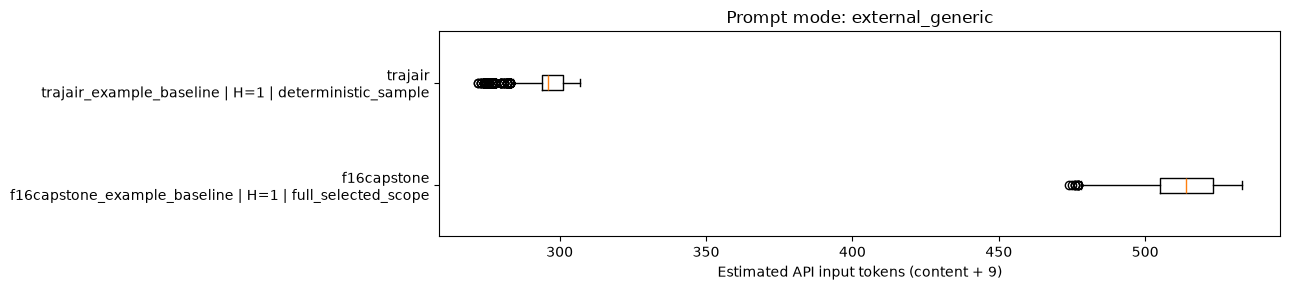

/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_56981/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


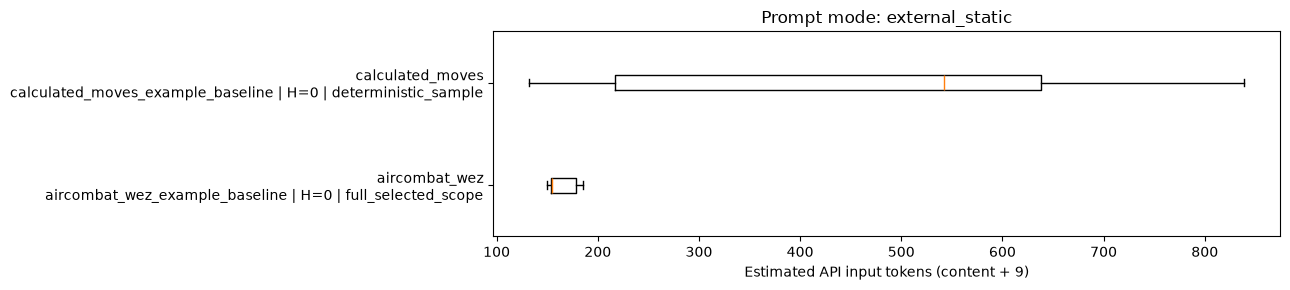

In [15]:
import matplotlib.pyplot as plt
for mode, mode_df in all_token_queries_df.groupby("prompt_mode", sort=True):
    grouped = list(mode_df.groupby(["dataset_id", "preprocessing_name", "history_size", "count_scope"], sort=True))
    labels = [f"{key[0]}\n{key[1]} | H={key[2]} | {key[3]}" for key, _ in grouped]
    values = [group["estimated_api_input_tokens"].to_numpy() for _, group in grouped]
    fig, ax = plt.subplots(figsize=(13, max(3, 0.65 * len(grouped))))
    ax.boxplot(values, vert=False)
    ax.set_yticks(range(1, len(labels) + 1), labels)
    ax.set_xlabel("Estimated API input tokens (content + 9)")
    ax.set_title(f"Prompt mode: {mode}")
    fig.tight_layout()
    plt.show()


## 14. largest/smallest token queries → raw/prompt drill-down

以下の行を見て「drill-down selection」の選択値を変更してください。
前処理設定・H・metric/questionも一致させ、raw表示から選択queryのtoken計測まで再実行すると同じpromptを確認できます。
各query行に実効設定JSONとSHA256を保持しています。


In [16]:
largest_token_queries_df = all_token_queries_df.nlargest(20, "estimated_api_input_tokens")
smallest_token_queries_df = all_token_queries_df.nsmallest(20, "estimated_api_input_tokens")
drill_columns = query_columns + ["metric", "question_name"]
show_frame(largest_token_queries_df[drill_columns], title="Largest 20 counted queries")
show_frame(smallest_token_queries_df[drill_columns], title="Smallest 20 counted queries")
example = largest_token_queries_df.iloc[0]
print("Example selection — copy into drill-down selection:")
print("DATASET =", repr(example["dataset_id"]))
print("EPISODE =", int(example["episode_id"]) if pd.notna(example["episode_id"]) else None)
print("SEQUENCE_ID =", int(example["sequence_id"]))
print("ROW_ID =", int(example["row_id"]) if pd.notna(example["row_id"]) else None)
print("INDEX =", int(example["query_index"]))
print("HISTORY_SIZE =", int(example["history_size"]))
print("Metric/question:", example["metric"], example["question_name"])
print("Effective preprocessing JSON:", example["preprocessing_config"])


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
48912,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/mixed/20180108112738/blue1.csv,<NA>,120,12848,29,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,839,22,808,797,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48929,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red/20180105142432/blue1.csv,<NA>,463,49772,7,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,823,22,792,781,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48939,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red/20180105152401/blue1.csv,<NA>,624,67194,87,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,821,22,790,779,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48948,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red_evading/20180105184622/blue1.csv,<NA>,855,92103,114,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,821,22,790,779,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48961,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red_range50/20180105160506/blue1.csv,<NA>,1100,118462,83,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,821,22,790,779,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50754,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-transfer-with-mixed-as-source/red/20150408113422/blue2.csv,<NA>,27762,4923661,34,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,818,22,787,776,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50757,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-transfer-with-mixed-as-source/red/20150408123514/blue2.csv,<NA>,27906,4942694,77,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,818,22,787,776,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48946,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red_evading/20180105182555/blue1.csv,<NA>,806,86798,87,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,817,22,786,775,11,deterministic_sample,2804268,2000,0,representation,baseline_description
48958,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 3 - Team coordination/Chapter 3 - Team coordination/cent/red_evading/20180105193301/blue1.csv,<NA>,1016,109463,132,0,external_static,calculated_moves_example_basel

,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
50167,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527145405/red2.csv,<NA>,21108,3430469,200,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50171,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527145435/red2.csv,<NA>,21132,3436626,42,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50183,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527151642/red2.csv,<NA>,21220,3459985,246,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50189,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527153626/red2.csv,<NA>,21284,3476609,30,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50256,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527183911/red2.csv,<NA>,21948,3651513,219,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50270,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527191539/red2.csv,<NA>,22076,3685066,92,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,132,22,101,90,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50158,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527143440/red2.csv,<NA>,21004,3403090,186,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,133,22,102,91,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50165,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/20150527143758/red2.csv,<NA>,21060,3417865,226,0,external_static,calculated_moves_example_baseline,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,133,22,102,91,11,deterministic_sample,2804268,2000,0,representation,baseline_description
50169,calculated_moves,data/candidate_datasets/calculated_moves/extracted/Dataset Calculated Moves/Chapter 5 - Transfer learning/Chapter 5 - Transfer learning/2v2-no-transfer/lead-trail/2015052714542

Example selection — copy into drill-down selection:
DATASET = 'calculated_moves'
EPISODE = None
SEQUENCE_ID = 120
ROW_ID = 12848
INDEX = 29
HISTORY_SIZE = 0
Metric/question: representation baseline_description
Effective preprocessing JSON: {"action_columns":[],"dataset_id":"calculated_moves","fields":"*","history_size":0,"name":"calculated_moves_example_baseline","prompt_mode":"external_static","question":"Summarize this record using only its available fields.","reward_column":null,"selector_scope":"csv_table","source_globs":["data/candidate_datasets/calculated_moves/**/*.csv"],"state_columns":[],"system_prompt":"Describe the supplied encounter statistics, rule weights, or fitness fields. These are not timestep flight states or actions.","value_format":"lexical"}


## 15. optional: Saved batch resultsとのvalidation

read_batch_summary()はここだけで使用します。LIVE結果がprimaryです。
同じdataset・mode・H・設定SHA・model/tokenizer・sampling条件の集計値を比較し、savedのみのHも明示します。
比較は集計値レベルです。prompt全文の厳密一致を調べる場合はquery-levelのprompt SHAを照合してください。
savedがなければ表示するだけで、追加batchは起動しません。


In [17]:
saved_token_summary = read_batch_summary()
saved_metadata_path = ROOT / "outputs/token_counts/summary.json"
if saved_token_summary is None or not saved_metadata_path.is_file():
    print("Token batch has not been executed yet.")
else:
    saved_token_summary = saved_token_summary.loc[saved_token_summary["dataset_id"].isin(EXTERNAL)].copy()
    saved_metadata = json.loads(saved_metadata_path.read_text())
    saved_token_validation_df = compare_saved_tokens(result, saved_token_summary, saved_metadata)
    show_frame(saved_token_validation_df, title="LIVE vs SAVED token aggregates")
    print("Matched aggregates:", int(saved_token_validation_df.matches.sum()))
    print("Saved results read only; no CSV/JSON was overwritten.")


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,n_units_live,eligible_query_pool_live,sample_size_live,seed_live,count_scope_live,mean_input_tokens_live,std_input_tokens_live,min_input_tokens_live,median_input_tokens_live,p95_input_tokens_live,max_input_tokens_live,total_input_tokens_live,n_units_saved,eligible_query_pool_saved,sample_size_saved,seed_saved,count_scope_saved,mean_input_tokens_saved,std_input_tokens_saved,min_input_tokens_saved,median_input_tokens_saved,p95_input_tokens_saved,max_input_tokens_saved,total_input_tokens_saved,presence,matches,model_tokenizer_match,comparison_note
0,aircombat_wez,external_static,0,72ea28a57e92d6cbb7ec3226e3084d2177924883949969a90d1ce55d9d23d960,3864,3864,3864,0,"""full_selected_scope""",162.13768115942028,12.68982933439303,150,155,185,185,626500,3864,3864,3864,0,"""full_selected_scope""",162.13768115942028,12.68982933439303,150,155,185,185,626500,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
1,calculated_moves,external_static,0,1dd94d0c2a0311fcee44558db26499007cb1d2678c63569c564813a8d15a75c3,2000,2804268,2000,0,"""deterministic_sample""",448.6165,210.15507947168445,132,542,701,839,897233,2000,2804268,2000,0,"""deterministic_sample""",448.6165,210.15507947168445,132,542,701,839,897233,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
2,f16capstone,external_generic,1,ef9adf3128e794e81dc28802cea785020d7dd35fd79635d80f5622a8213930b5,43041,43041,43041,0,"""full_selected_scope""",512.7735879742571,11.641787039542631,474,514,527,533,22070288,43041,43041,43041,0,"""full_selected_scope""",512.7735879742571,11.641787039542631,474,514,527,533,22070288,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
3,trajair,external_generic,1,51625d7127ccf1546c48ce54930ff085ed16cf75f9a0e5d39074743059f9bcf8,2000,2724711,2000,0,"""deterministic_sample""",295.898,7.084885037881701,272,296,304,307,591796,2000,2724711,2000,0,"""deterministic_sample""",295.898,7.084885037881701,272,296,304,307,591796,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison


Matched aggregates: 4
Saved results read only; no CSV/JSON was overwritten.


In [18]:

assert result.metadata['api_requests'] == 0
assert len(largest_token_queries_df) == 20
assert selected_tokens is not None
for name, table in raw_validation.items():
    assert {'matches', 'presence'} <= set(table.columns)
    print('Saved raw comparison:', name, 'differences:', int((~table.matches).sum()))
if 'saved_token_validation_df' in globals():
    assert saved_token_validation_df.query("presence == 'both'").matches.all()

assert len(external_files_df) == len(candidate_inventory['files'])
assert candidate_inventory['source_size_mtime_unchanged']
assert not external_files_df.query("status == 'error'").shape[0]
assert len(all_token_queries_df) == 50905
assert all_token_queries_df.dataset_id.nunique() == 4
assert set(all_token_queries_df.dataset_id) <= set(EXTERNAL)
assert len(token_skipped_df) == 1
assert set(token_scopes_df.query("count_scope == 'deterministic_sample'").dataset_id) == {'trajair', 'calculated_moves'}
import hashlib
r = all_token_queries_df.query("dataset_id == 'f16capstone'").iloc[10]
with inventory_context({'tasks': []}, candidate_inventory):
    ext = get_adapter('f16capstone')
seq, raw = select_record(ext, sequence_id=int(r.sequence_id), index=int(r.query_index))
cfg, _ = preprocessing_for_inspection('f16capstone', 'configs/preprocessing/f16capstone_default.yaml')
q = selected_query(ext, seq, int(r.query_index), cfg, int(r.history_size))
assert hashlib.sha256(q.user_prompt.encode()).hexdigest() == r.user_prompt_sha256


Saved raw comparison: external_files differences: 10
Saved raw comparison: external_columns differences: 0
Saved raw comparison: external_arrays differences: 0
